In [314]:
with open('data/input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [315]:
print('length of the dataset in characters:', len(text))

length of the dataset in characters: 1115394


In [316]:
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [317]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print('vocab:', ''.join(chars))
print('vocab size:', vocab_size)

vocab: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65


In [318]:
chars

['\n',
 ' ',
 '!',
 '$',
 '&',
 "'",
 ',',
 '-',
 '.',
 '3',
 ':',
 ';',
 '?',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [319]:
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[ch] for ch in s]
decode = lambda es: ''.join([itos[i] for i in es])

print(encode('hi there'))
print(decode(encode('hi there')))


[46, 47, 1, 58, 46, 43, 56, 43]
hi there


In [320]:
import torch

data = torch.tensor(encode(text), dtype=torch.long)

print(data.shape, data.dtype)
print(data[:1000])

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [321]:
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

In [322]:
block_size = 8 
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f'if the input is {context}, then the target: {target}')

if the input is tensor([18]), then the target: 47
if the input is tensor([18, 47]), then the target: 56
if the input is tensor([18, 47, 56]), then the target: 57
if the input is tensor([18, 47, 56, 57]), then the target: 58
if the input is tensor([18, 47, 56, 57, 58]), then the target: 1
if the input is tensor([18, 47, 56, 57, 58,  1]), then the target: 15
if the input is tensor([18, 47, 56, 57, 58,  1, 15]), then the target: 47
if the input is tensor([18, 47, 56, 57, 58,  1, 15, 47]), then the target: 58


In [323]:
torch.manual_seed(1337)

batch_size = 4
block_size = 8
n_embd = 32

def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size, ))
    
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])

    return x, y
    
xb, yb = get_batch('train')

print("inputs:")
print(xb.shape)
print(xb)

print("targets:")
print(yb.shape)
print(yb)


inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])


In [324]:
y

tensor([47, 56, 57, 58,  1, 15, 47, 58])

In [454]:
import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(1337)

class Head(nn.Module):
    
    def __init__(self, head_size):
        super().__init__()
        self.head_size = head_size
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        
    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x) # (B,T,C), where C is head_size
        q = self.query(x) # (B,T,C)
        
        wei = q @ k.transpose(-2, -1) * self.head_size**-1 # (B,T,C) @ (B, C, T) --> (B,T,T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B,T,T)
        wei = F.softmax(wei, dim=-1) # (B,T,T)
        
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B,T,T) @ (B,T,C) --> (B,T,C)
        return out

     
class BigramLanguageModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.sa_head = Head(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        
        
    def forward(self, idx, targets=None):
        B, T = idx.shape
        
        # idx and targets are both (B,T) tensor of ints
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T)) # (T, C)
        
        x = tok_emb + pos_emb # (B,T,C)
        x = self.sa_head(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)
        
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
            
        return logits, loss
        
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:,-block_size:]
            logits, loss = self(idx_cond)

            logits = logits[:, -1, :]
            
            probs = F.softmax(logits, dim=-1)
            
            idx_next = torch.multinomial(probs, num_samples=1)
            
            idx = torch.cat((idx, idx_next), dim=1)
        return idx
            
            
m = BigramLanguageModel()
logits, loss = m(xb, yb)

In [455]:
idx = torch.zeros((1,1), dtype=torch.long)
print(decode(m.generate(idx, max_new_tokens=100)[0].tolist()))


ee'nCXLFs?Z,gfrx.dJ$tRFCEun U3pmPej3Pt-y?'SwrWl!LK-RI,IwIR$&,?cnIMN'wONtErKcfjmKZvF,GvpzGweVoHSrQJs,


In [456]:
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [457]:
batch_size = 32

for step in range(10000):
    xb, yb = get_batch('train')
    optimizer.zero_grad(set_to_none=True)
    logits, loss = m(xb, yb)
    loss.backward()
    optimizer.step()
    
print(loss.item())

2.307636260986328


In [ ]:
print(decode(m.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=100)[0].tolist()))

IndexError: index out of range in self

### The mathematical trick in self-attention

In [355]:
torch.manual_seed(1337)
    
B, T, C = (4, 8, 2)

x = torch.randn(B,T,C)
x.shape


torch.Size([4, 8, 2])

In [339]:
torch.manual_seed(42)
a = torch.tril(torch.ones(3,3))
a = a/a.sum(dim=1, keepdim=True)
b = torch.randint(0, 10, (3,2)).float()

print(a)
c = a@b
print(b)

print(c)

tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [340]:
wei = torch.tril(torch.ones(T,T))
wei = wei / wei.sum(dim=1, keepdim=True)
xbow2 = wei @ x # (T,T) @ (B,T,C) --> (B,T,C)
print(wei.shape, x.shape)

torch.Size([8, 8]) torch.Size([4, 8, 2])


In [348]:
# version 2: use softmax

tril = torch.tril(torch.ones(T,T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))

wei = F.softmax(wei, dim=-1)
print('wei.shape=', wei.shape, 'x.shape=',x.shape)
xbow3 = wei @ x

torch.allclose(xbow2, xbow3)

wei.shape= torch.Size([8, 8]) x.shape= torch.Size([4, 8, 32])


RuntimeError: The size of tensor a (2) must match the size of tensor b (32) at non-singleton dimension 2

In [376]:
# version 3: self-attention

# version 2: use softmax

torch.manual_seed(1337)

B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
k = key(x) # (B,T,16)
q = query(x) # (B,T,16)
wei= (q@k.transpose(-1,-2)) / head_size**0.5 

tril = torch.tril(torch.ones(T,T))
# wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))

wei = F.softmax(wei, dim=-1)
v = value(x)
xbow4 = wei @ v
print(xbow4.shape)

torch.Size([4, 8, 16])


In [389]:
k = torch.randn(B,T,16)
q = torch.randn(B,T,16)
wei= (q@k.transpose(-1,-2)) / head_size**0.5 


In [390]:
k.var()

tensor(1.0632)

In [391]:
q.var()

tensor(0.9891)

In [392]:
wei.var()

tensor(0.9755)

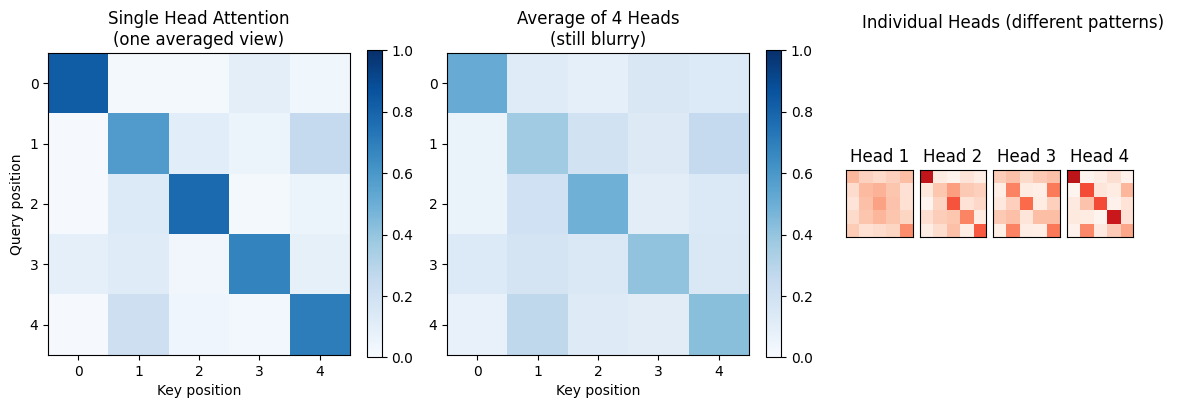

Single head avg entropy: 0.886
Head 1 avg entropy: 1.552
Head 2 avg entropy: 1.232
Head 3 avg entropy: 1.354
Head 4 avg entropy: 1.021

→ Multi‑heads have different entropy values, meaning they learn different attention distributions.


In [460]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Create a simple sequence of embeddings
# -------------------------------
# 5 tokens (e.g., words), each with 8-dimensional features
seq_len = 5
d_model = 8
np.random.seed(42)
X = np.random.randn(seq_len, d_model)  # (T, C)

# -------------------------------
# 2. Single‑head attention (scaled dot‑product)
# -------------------------------
def softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

def single_head_attention(X):
    # Simple self‑attention: Q = K = V = X (no projections for clarity)
    scores = X @ X.T  # (T, T)
    scores /= np.sqrt(d_model)
    weights = softmax(scores, axis=-1)
    output = weights @ X
    return weights, output

single_weights, _ = single_head_attention(X)

# -------------------------------
# 3. Multi‑head attention (4 heads, each on a subspace)
# -------------------------------
def multi_head_attention(X, num_heads=4):
    d_head = d_model // num_heads  # 8 // 4 = 2
    heads_weights = []
    for h in range(num_heads):
        # Project onto a lower‑dim subspace (take consecutive slices)
        start = h * d_head
        end = start + d_head
        X_sub = X[:, start:end]  # (T, d_head)
        # Self‑attention inside this subspace
        scores = X_sub @ X_sub.T
        scores /= np.sqrt(d_head)
        weights = softmax(scores, axis=-1)
        heads_weights.append(weights)
    # Average weights across heads (just for visual comparison)
    avg_multi_weights = np.mean(heads_weights, axis=0)
    return heads_weights, avg_multi_weights

heads_weights, avg_multi_weights = multi_head_attention(X, num_heads=4)

# -------------------------------
# 4. Visualise: single head vs average of multi‑head
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
im0 = axes[0].imshow(single_weights, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title("Single Head Attention\n(one averaged view)")
axes[0].set_xlabel("Key position")
axes[0].set_ylabel("Query position")

im1 = axes[1].imshow(avg_multi_weights, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title("Average of 4 Heads\n(still blurry)")
axes[1].set_xlabel("Key position")

# Show each head individually
head_imgs = []
for h in range(4):
    ax = axes[2].inset_axes([h*0.22, 0, 0.2, 1])
    im = ax.imshow(heads_weights[h], cmap='Reds', vmin=0, vmax=1)
    ax.set_title(f"Head {h+1}")
    ax.set_xticks([])
    ax.set_yticks([])
    head_imgs.append(im)
axes[2].set_title("Individual Heads (different patterns)")
axes[2].axis('off')

plt.colorbar(im0, ax=axes[0], fraction=0.046)
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

# -------------------------------
# 5. Quantify diversity
# -------------------------------
def entropy_of_attention(weights):
    # Higher entropy = more uniform attention
    return -np.sum(weights * np.log(weights + 1e-8), axis=-1).mean()

single_entropy = entropy_of_attention(single_weights)
multi_entropies = [entropy_of_attention(w) for w in heads_weights]

print(f"Single head avg entropy: {single_entropy:.3f}")
for h, ent in enumerate(multi_entropies):
    print(f"Head {h+1} avg entropy: {ent:.3f}")
print("\n→ Multi‑heads have different entropy values, meaning they learn different attention distributions.")

In [29]:
import torch.nn.functional as F
torch.manual_seed(1337)

class LayerNorm1d(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_normalized + self.beta

x = torch.randn(32, 100)
ln = LayerNorm1d(100)
x = ln(x)



In [ ]:
torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
    
    ]).sum(dim=1)

tensor([5., 7., 9.])

In [27]:
x[:, 0].mean(), x[:, 0].var()

(tensor(0.1392), tensor(0.7920))

In [30]:
x[0, :].mean(), x[0, :].var()

(tensor(-2.3842e-09), tensor(1.0101))